In [146]:
import pandas as pd
import numpy as np
import plotly.express as px

file = '/Users/jonzimmerman/Desktop/Data Projects/AllTrails/synthetic_hiking_reviews.csv'
df = pd.read_csv(file)
print(df.shape)

(4263, 10)


In [147]:
df.head()

,review_id,trail_name,state,latitude,longitude,difficulty,elevation_gain_ft,rating,date,review_text
0,1,Silver Star Mountain via South Ridge,Washington,45.782,-122.292,4,3238,4,2025-04-22,"Solid hike, definitely a burner today! The Sou..."
1,2,Silver Star Mountain via South Ridge,Washington,45.782,-122.292,4,3238,4,2021-10-23,Fog rolled in thick as I climbed up Silver Sta...
2,3,Silver Star Mountain via South Ridge,Washington,45.782,-122.292,4,3238,4,2021-06-15,"This was a good climb, definitely earned the 4..."
3,4,Silver Star Mountain via South Ridge,Washington,45.782,-122.292,4,3238,3,2023-08-10,"August 10th was a beautiful day for a climb, b..."
4,5,Silver Star Mountain via South Ridge,Washington,45.782,-122.292,4,3238,3,2023-08-30,August 30th was a decent day for this climb – ...


### Daily and Monthly Plots

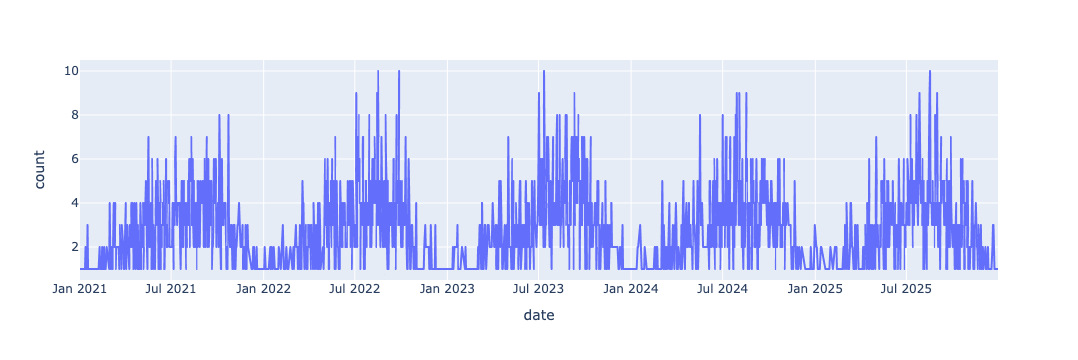

In [163]:
df_daily_counts = df.groupby("date").size().reset_index(name="count")
px.line(df_counts, x="date", y="count")

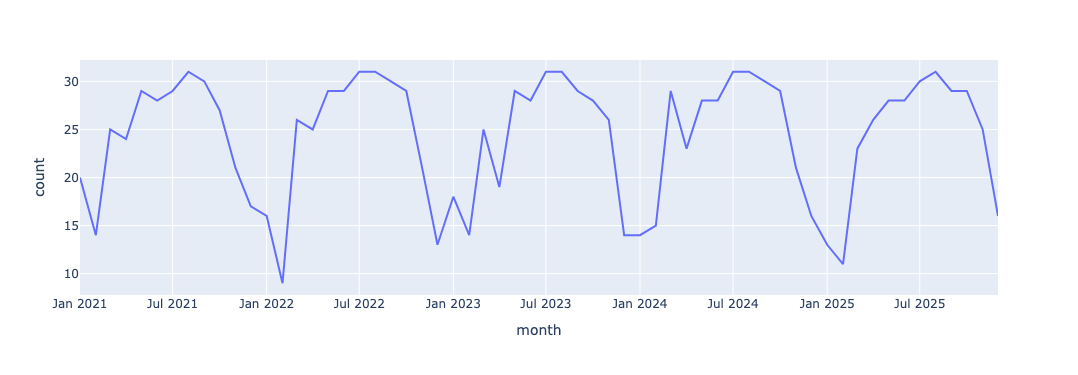

In [178]:
df_daily_counts["month"] = pd.to_datetime(df_daily_counts["date"]).dt.to_period("M").dt.to_timestamp()
df_monthly_counts = df_daily_counts.groupby("month").size().reset_index(name="count")
px.line(df_monthly_counts, x = 'month', y = 'count')

In [193]:
df_monthly_counts = df.groupby(["date", "rating"]).size().reset_index(name="count")
df_monthly_counts["month"] = pd.to_datetime(df_monthly_counts["date"]).dt.to_period("M").dt.to_timestamp()
df_monthly_counts = df_monthly_counts.groupby(["month", "rating"]).size().reset_index(name="count")


df_monthly_counts["weighted_rating"] = df_monthly_counts["rating"] * df_monthly_counts["count"]

df_monthly_summary = df_monthly_counts.groupby("month").agg(
    review_count=("count", "sum"),
    total_rating=("weighted_rating", "sum")
).reset_index()

df_monthly_summary["avg_rating"] = df_monthly_summary["total_rating"] / df_monthly_summary["review_count"]
df_monthly_summary


,month,review_count,total_rating,avg_rating
0,2021-01-01,21,77,3.666667
1,2021-02-01,16,60,3.750000
2,2021-03-01,41,151,3.682927
3,2021-04-01,39,149,3.820513
4,2021-05-01,61,231,3.786885


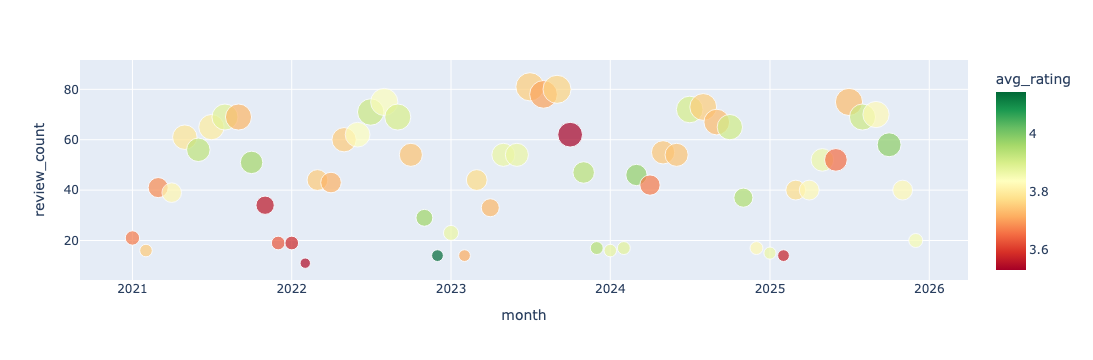

In [197]:
px.scatter(
    df_monthly_summary,
    x="month",
    y="review_count",
    color="avg_rating",
    color_continuous_scale="RdYlGn",
    size="review_count"
)

### Plot Monthly Reviews by Trail

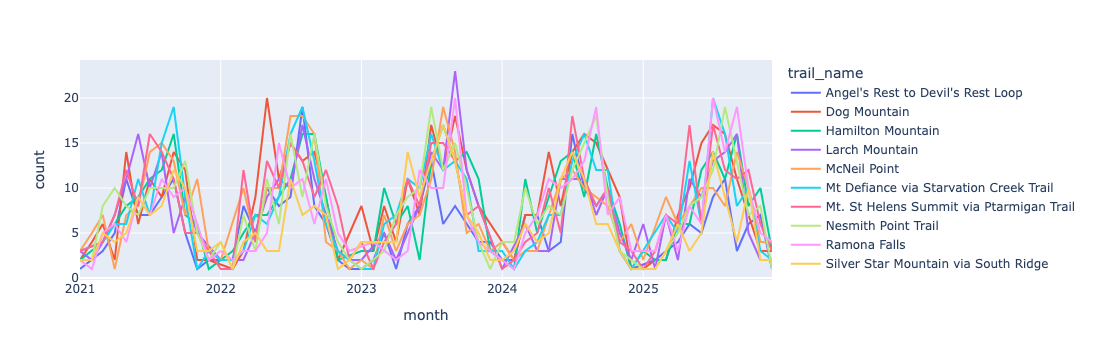

In [209]:
df_monthly_trail_counts = df.groupby(["month", "trail_name"]).size().reset_index(name="count")
px.line(df_monthly_trail_counts, x = 'month', y = 'count', color = 'trail_name')

In [211]:
df_monthly_trail_counts = df.groupby(["month", "trail_name", "rating"]).size().reset_index(name="count")
df_monthly_trail_counts["weighted_rating"] = df_monthly_trail_counts["rating"] * df_monthly_trail_counts["count"]

df_monthly_trail_summary = df_monthly_trail_counts.groupby(["month","trail_name"]).agg(
    review_count=("count", "sum"),
    total_rating=("weighted_rating", "sum")
).reset_index()

df_monthly_trail_summary["avg_rating"] = df_monthly_trail_summary["total_rating"] / df_monthly_trail_summary["review_count"]
df_monthly_trail_summary.head()

,month,trail_name,review_count,total_rating,avg_rating
0,2021-01-01,Angel's Rest to Devil's Rest Loop,1,4,4.000000
1,2021-01-01,Dog Mountain,2,6,3.000000
2,2021-01-01,Hamilton Mountain,2,8,4.000000
3,2021-01-01,Larch Mountain,3,11,3.666667
4,2021-01-01,McNeil Point,3,11,3.666667


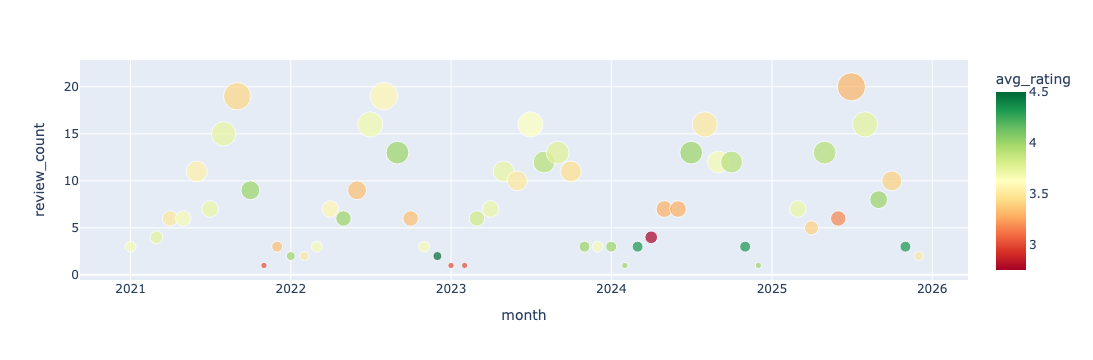

In [217]:
px.scatter(
    df_monthly_trail_summary[df_monthly_trail_summary['trail_name']=='Mt Defiance via Starvation Creek Trail'],
    x="month",
    y="review_count",
    color="avg_rating",
    color_continuous_scale="RdYlGn",
    size="review_count"
)

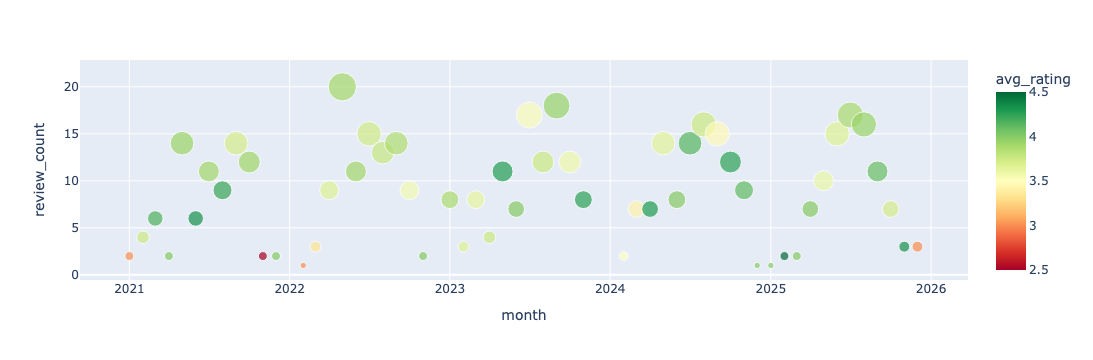

In [218]:
px.scatter(
    df_monthly_trail_summary[df_monthly_trail_summary['trail_name']=='Dog Mountain'],
    x="month",
    y="review_count",
    color="avg_rating",
    color_continuous_scale="RdYlGn",
    size="review_count"
)

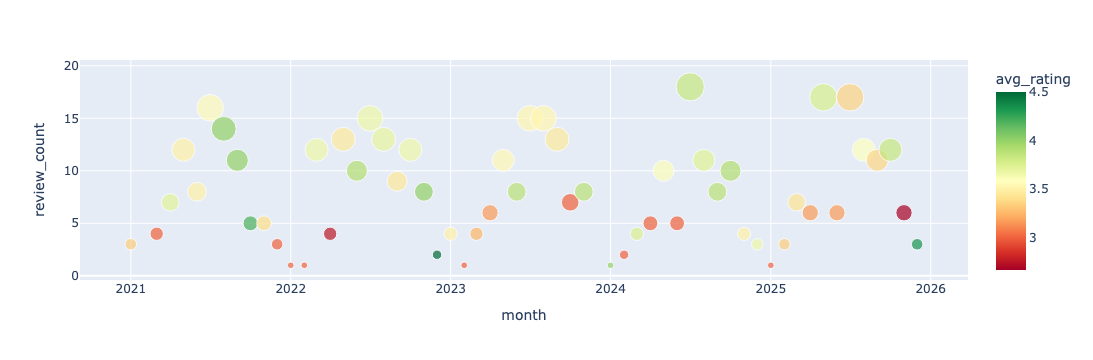

In [220]:
px.scatter(
    df_monthly_trail_summary[df_monthly_trail_summary['trail_name']=='Mt. St Helens Summit via Ptarmigan Trail'],
    x="month",
    y="review_count",
    color="avg_rating",
    color_continuous_scale="RdYlGn",
    size="review_count"
)